In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

In [2]:
n_curves = 10000
N = 100
t_array = np.linspace(0,2*np.pi,N)
base_array = np.zeros((n_curves,N))

A = np.random.uniform(0.25,1.5,n_curves)
omega = np.random.uniform(0.5,2,n_curves)
phi = np.random.uniform(0, 2*np.pi, n_curves)

for i, n in enumerate(base_array):
    for j in range (N):
        n[j] = A[i]*np.sin(omega[i]*t_array[j]+ phi[i])
base_array.shape

(10000, 100)

In [3]:
dist = np.random.normal
noise_sigma = 0.2 

noise_array = np.zeros((n_curves,N))
for i, n in enumerate(noise_array):
    for j in range (N):
        n[j] = base_array[i][j] + dist(0,noise_sigma,1)[0]

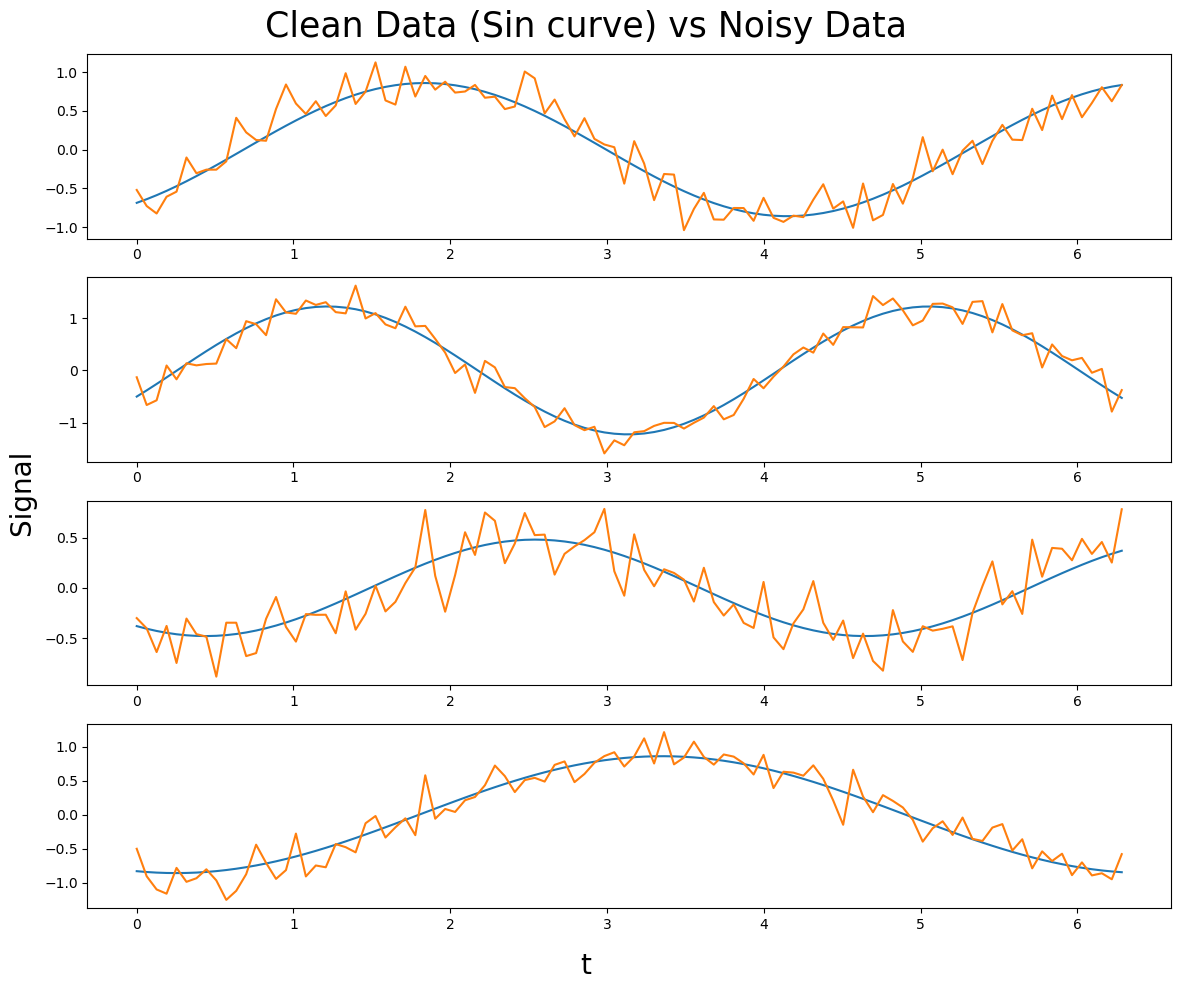

In [4]:
sample = [0,1,2,3]
fig, ax = plt.subplots(4,figsize=(12, 10))
for i,n in enumerate(sample):
    ax[i].plot(t_array, base_array[n])
    ax[i].plot(t_array,noise_array[n])
fig.suptitle("Clean Data (Sin curve) vs Noisy Data",fontsize = "25")
fig.supxlabel("t", fontsize = "20")
fig.supylabel("Signal ", fontsize = "20")

fig.tight_layout()

In [5]:
Ratio = 0.9 

split_i = int(Ratio * n_curves)
base_train,base_valid = np.split(base_array,[split_i],0)
noise_train,noise_valid = np.split(noise_array,[split_i],0)

In [6]:
autoencoder = Sequential([
    Input(shape=(N,)),           #  Input layer
    Dense(64, activation='relu'),  
    Dense(16, activation='relu'),  # latent layer
    Dense(64, activation='relu'),
    Dense(N, activation='linear')  # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')

In [ ]:
# Train the model
Gauss_history = autoencoder.fit(
    noise_train, base_train,         # input = noisy, target = clean
    epochs=50,
    batch_size=128,
    validation_data=(noise_valid,base_valid)
)


Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2843 - val_loss: 0.0789
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 778us/step - loss: 0.0410 - val_loss: 0.0232
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step - loss: 0.0171 - val_loss: 0.0123
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - loss: 0.0103 - val_loss: 0.0083
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step - loss: 0.0070 - val_loss: 0.0064
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step - loss: 0.0054 - val_loss: 0.0053
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 749us/step - loss: 0.0046 - val_loss: 0.0046
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - loss: 0.0041 - val_loss: 0.0042
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - loss: 0.0038 - val_loss: 0.0038
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 758us/step - loss: 0.0035 - val_loss: 0.0036
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 733us/step - loss: 0.0033 - val_loss: 0.0036
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step -

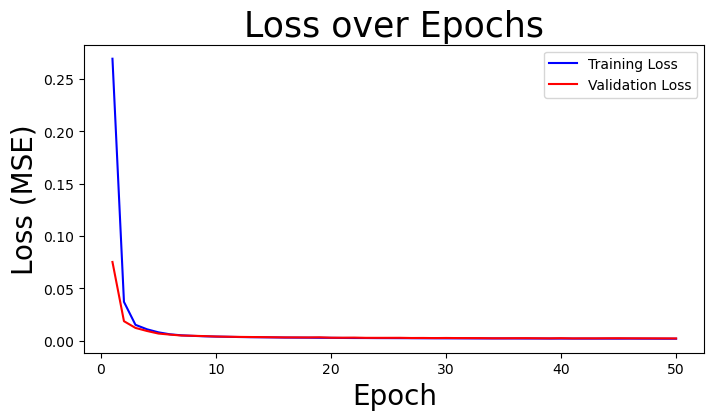

In [ ]:
train_loss = Gauss_history.history['loss']
val_loss = Gauss_history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

# Plot training loss
plt.figure(figsize=(8,4))
plt.plot(epochs, train_loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title("Loss over Epochs",fontsize = 25)
plt.xlabel("Epoch",fontsize = 20)
plt.ylabel("Loss (MSE)",fontsize = 20)
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


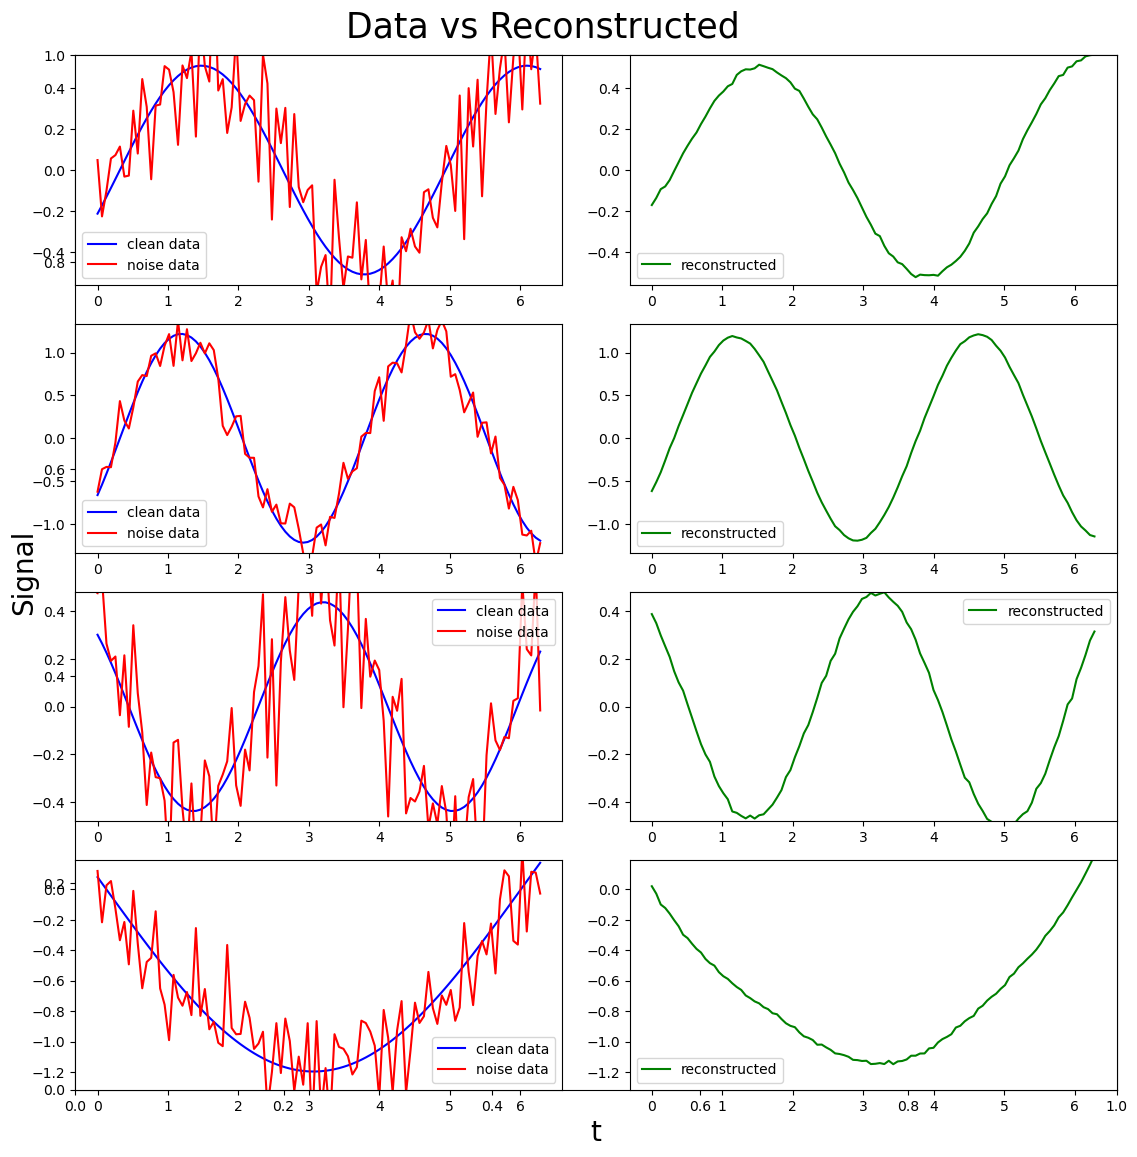

In [ ]:
# Reconstruct the noisy signals
reconstructed = autoencoder.predict(noise_array[sample])

plt.figure(figsize=(12, 12))
plt.xlabel("t",fontsize = 20)
plt.ylabel("Signal",fontsize = 20)
idx = 0
for i in sample:
    # Original
    y_range = [np.min(base_array[i])*1.1,np.max(base_array[i])*1.1]
    plt.subplot(len(sample), 2, 2*idx + 1)
    plt.plot(t_array, base_array[i], color='blue', label = "clean data")
    plt.plot(t_array, noise_array[i], color='red', label = "noise data")
    plt.ylim(y_range)
    plt.legend()

    # Reconstructed output
    plt.subplot(len(sample), 2, 2*idx + 2)
    plt.plot(t_array, reconstructed[idx], color='green',label = "reconstructed")
    plt.ylim(y_range)
    plt.legend()

    idx +=1
plt.suptitle("Data vs Reconstructed",fontsize = 25)
plt.tight_layout()
plt.show()

In [ ]:
def train_autoencoder(X, Y, train_frac=0.9, latent_dim=16):
    epochs = 50
    batch_size = 128
    num_samples = X.shape[0]
    split_idx = int(train_frac * num_samples)
    
    X_train, Y_train = X[:split_idx], Y[:split_idx]
    X_val, Y_val = X[split_idx:], Y[split_idx:]
    
    autoencoder = Sequential([
        Input(shape=(N,)),           
        Dense(64, activation='relu'),
        Dense(latent_dim, activation='relu'),
        Dense(64, activation='relu'),
        Dense(N, activation='linear')
    ])
    
    autoencoder.compile(optimizer=Adam(0.001), loss='mse')
    
    history = autoencoder.fit(
        X_train, Y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(noise_valid, base_valid),
        verbose=0
    )
    
    return autoencoder, history

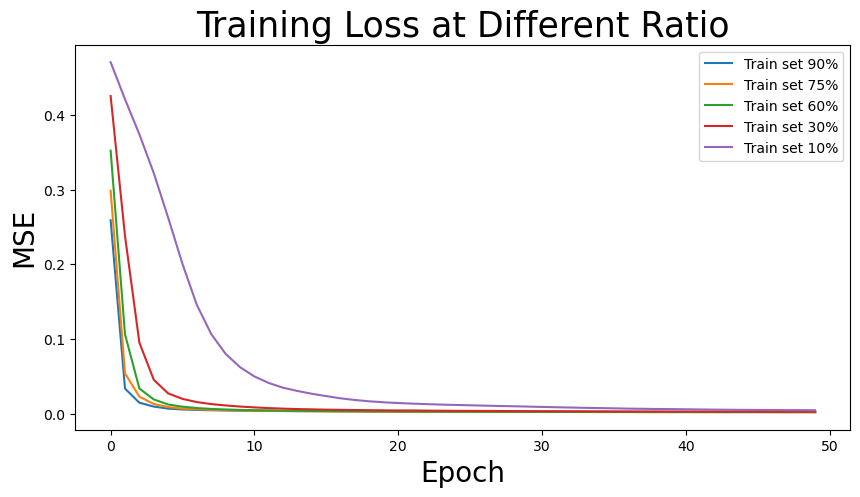

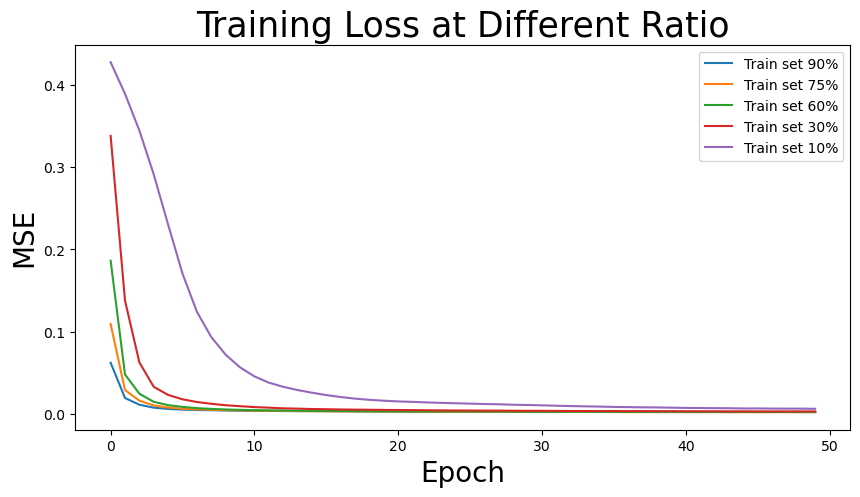

In [ ]:
fractions = [0.9, 0.75, 0.6, 0.3, 0.1] #different training fractions
histories = {}

for f in fractions:
    _,histories[f] = train_autoencoder(noise_array, base_array, train_frac=f)

# Plot TRAINING loss 
plt.figure(figsize=(10,5))
for f in fractions:
    plt.plot(histories[f].history['loss'], label=f'Train set {int(f*100)}%')
plt.xlabel("Epoch",fontsize = 20)
plt.ylabel("MSE",fontsize = 20)
plt.title("Training Loss at Different Ratio",fontsize = 25)
plt.legend()
plt.show()

# Plot VALIDATION loss 
plt.figure(figsize=(10,5))
for f in fractions:
    plt.plot(histories[f].history['val_loss'], label=f'Train set {int(f*100)}%')
plt.xlabel("Epoch",fontsize = 20)
plt.ylabel("MSE",fontsize = 20)
plt.title("Training Loss at Different Ratio",fontsize = 25)
plt.legend()
plt.show()

In [ ]:
bottleneck_sizes = [15, 10, 7, 5, 3, 1]

models = {}
histories_bottleneck = {}

for i in bottleneck_sizes:    
    model, history = train_autoencoder(
        noise_array,
        base_array,
        latent_dim=i
    )
    
    models[i] = model
    histories_bottleneck[i] = history

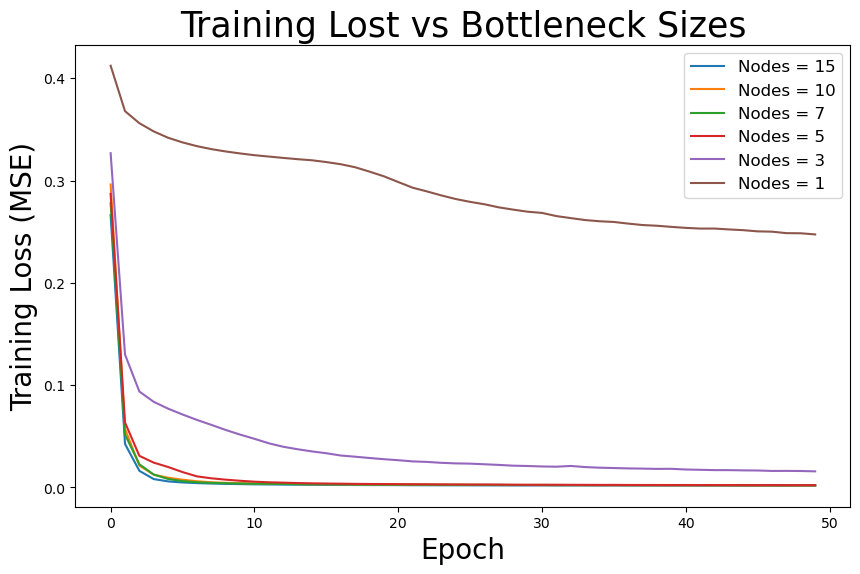

In [ ]:
plt.figure(figsize=(10,6))

for i in bottleneck_sizes:
    plt.plot(
        histories_bottleneck[i].history['loss'],
        label=f'Nodes = {i}'
    )

plt.xlabel("Epoch",fontsize = 20)
plt.ylabel("Training Loss (MSE)",fontsize = 20)
plt.title("Training Lost vs Bottleneck Sizes",fontsize = 25)
plt.legend(loc='upper right', fontsize=12)
plt.show()

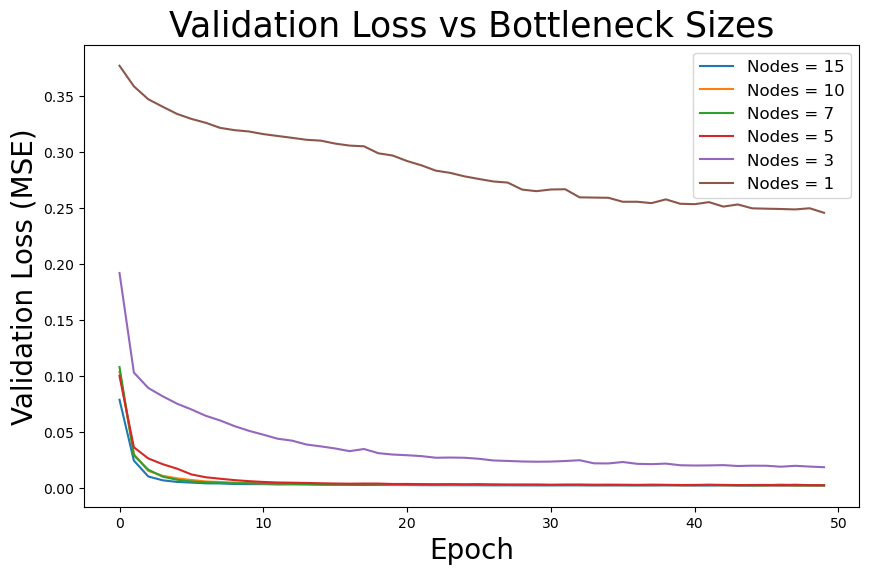

In [ ]:
plt.figure(figsize=(10,6))

for i in bottleneck_sizes:
    plt.plot(
        histories_bottleneck[i].history['val_loss'],
        label=f'Nodes = {i}'
    )

plt.xlabel("Epoch",fontsize = 20)
plt.ylabel("Validation Loss (MSE)",fontsize = 20)
plt.title("Validation Loss vs Bottleneck Sizes",fontsize = 25)
plt.legend(loc='upper right', fontsize=12)
plt.show()

In [ ]:
# scale factor to convert signal into "counts"
scale = 20  

# shift sine wave so it becomes positive
shifted_signal = base_array - base_array.min()

# convert to counts
counts = shifted_signal * scale

# apply Poisson noise
poisson_counts = np.random.poisson(counts)

# convert back to original signal scale
poisson_array = poisson_counts / scale + base_array.min()

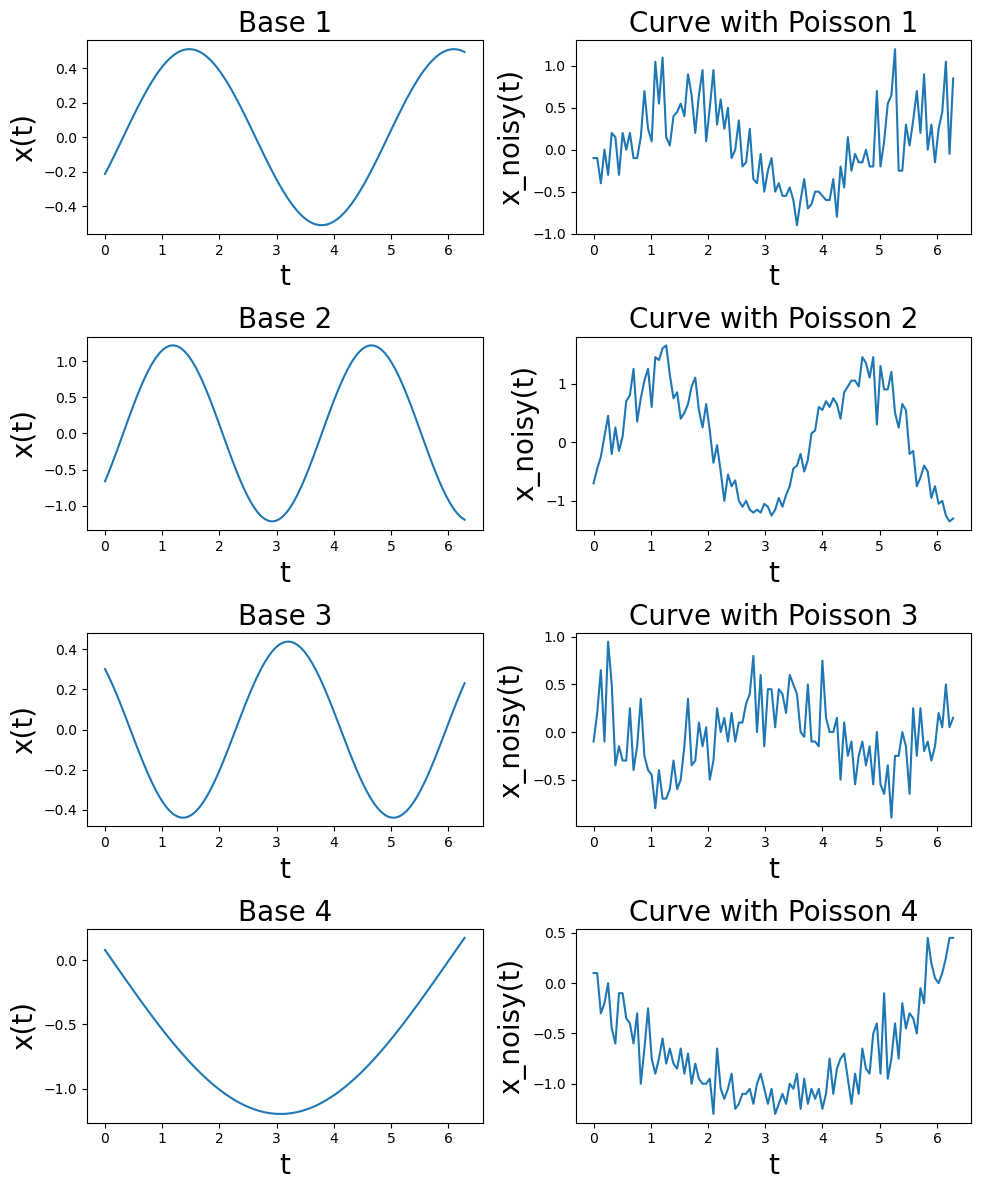

In [ ]:

plt.figure(figsize=(10,12))
a = 0

for i in sample:

    # clean curve
    plt.subplot(4,2,2*a+1)
    plt.plot(t_array, base_array[i])
    plt.title(f"Base {i+1}",fontsize = 20)
    plt.xlabel("t",fontsize = 20)
    plt.ylabel("x(t)",fontsize = 20)

    # poisson noisy curve
    plt.subplot(4,2,2*a+2)
    plt.plot(t_array, poisson_array[i])
    plt.title(f"Curve with Poisson {i+1}",fontsize = 20)
    plt.xlabel("t",fontsize = 20)
    plt.ylabel("x_noisy(t)",fontsize = 20)

    a += 1

plt.tight_layout()
plt.show()

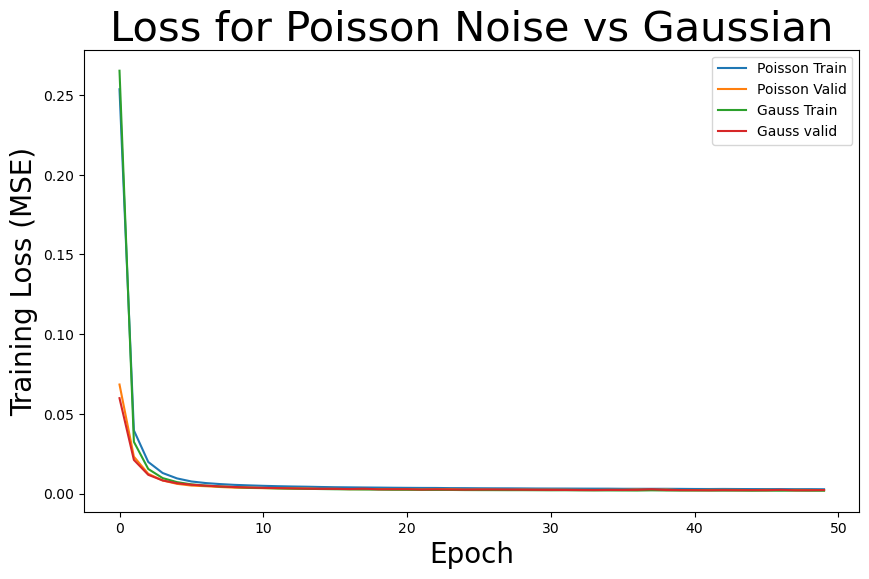

In [ ]:
autoencoder, history_poisson = train_autoencoder(
    poisson_array,
    base_array,
    train_frac=0.9,
    latent_dim=16
)

plt.figure(figsize=(10,6))
plt.plot(history_poisson.history['loss'], label = 'Poisson Train')
plt.plot(history_poisson.history['val_loss'],  label = 'Poisson Valid')
plt.plot(Gauss_history.history['loss'], label = 'Gauss Train')
plt.plot(Gauss_history.history['val_loss'], label = 'Gauss valid')
plt.xlabel("Epoch",fontsize = 20)
plt.ylabel("Training Loss (MSE)",fontsize = 20)
plt.title("Loss for Poisson Noise vs Gaussian",fontsize = 30)
plt.legend()
plt.show()